# Analiza podatkov: zaupanje skozi čas v sistem XAI

Magistrsko delo — *Zaupanje skozi čas: kako razlage vplivajo na dolgoročno zaupanje v sistem umetne inteligence*

**Podatki:** `anketa191776-2026-05-11_dataset_analiza_v13.csv`
Uporabljaj izključno različico **v13** ali novejšo. Starejše različice vsebujejo napake pri
čiščenju lestvic Q2 (1–7) in Q4B (1–5).

**Zgradba analize:**
1. Priprava podatkov
2. Eksploratorna analiza (grafi za hiter pregled)
3. Linearni mešani modeli — najprej zaupanje, nato ostale dimenzije

**Merjene dimenzije in njihove lestvice:**

| Dimenzija | Postavke | Lestvica | Cronbach α |
|---|---|---|---|
| Zaupanje | Q4Aa–Q4Ag | 1–7 | 0,946 |
| Nezaupanje | Q4Ba–Q4Be | 1–5 | 0,808 |
| Zadovoljstvo z razlago | Q2a–Q2h | 1–7 | 0,934 |
| Izvedljivost | Q3a–Q3g | 1–5 | 0,892 |
| Mentalni model | 11 nalog | delež 0–1 | — |

## 1. Priprava podatkov

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

PODATKI = "../Izvozi/analysis_outputs_2026_05_11/anketa191776-2026-05-11_dataset_analiza_v13.csv"
GRAFI = Path("grafi")
GRAFI.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
df = pd.read_csv(PODATKI, encoding="utf-8-sig")

# Obdrzimo samo veljavne enote: zakljucena anketa, brez testnih vnosov,
# z razresljivo 8-mestno kodo udelezenca.
df = df[df["analiza_valid_resolved"] == True].copy()

# Tip pristranskosti kot faktor. Referencna kategorija je "brez_biasa",
# zato se oba pristranska pogoja primerjata z njo.
df["bias"] = pd.Categorical(
    df["analiza_bias_type"],
    categories=["brez_biasa", "pozitivni_bias_nacionalnost", "negativni_bias_nacionalnost"],
)

print(f"Veljavnih enot:  {len(df)}")
print(f"Udelezencev:     {df['analiza_resolved_code'].nunique()}")
print(f"Zaporednih ogledov: {int(df['analiza_view_number'].min())}-{int(df['analiza_view_number'].max())}")
df["bias"].value_counts()

Veljavnih enot:  267
Udelezencev:     82
Zaporednih ogledov: 1-6


bias
brez_biasa                     180
negativni_bias_nacionalnost     45
pozitivni_bias_nacionalnost     42
Name: count, dtype: int64

In [3]:
# Slovarji za dimenzije: ime -> (stolpec, lestvica)
DIMENZIJE = {
    "Zaupanje":               ("analiza_faktor_zaupanje_mean",      "1-7"),
    "Nezaupanje":             ("analiza_faktor_nezaupanje_mean",    "1-5"),
    "Zadovoljstvo z razlago": ("analiza_zadovoljstvo_q2_mean",      "1-7"),
    "Izvedljivost":           ("analiza_izvedljivost_q3_mean",      "1-5"),
    "Mentalni model":         ("analiza_mm_total_correct_share",    "0-1"),
}

opis = pd.DataFrame(
    [
        {
            "dimenzija": ime,
            "lestvica": lestvica,
            "N": int(df[stolpec].notna().sum()),
            "M": round(df[stolpec].mean(), 2),
            "SD": round(df[stolpec].std(), 2),
            "min": round(df[stolpec].min(), 2),
            "max": round(df[stolpec].max(), 2),
        }
        for ime, (stolpec, lestvica) in DIMENZIJE.items()
    ]
)
opis

,dimenzija,lestvica,N,M,SD,min,max
0,Zaupanje,1-7,238,4.05,1.36,1.00,7.00
1,Nezaupanje,1-5,238,2.79,0.81,1.00,5.00
2,Zadovoljstvo z razlago,1-7,267,4.61,1.23,1.12,7.00
3,Izvedljivost,1-5,267,3.54,0.75,1.57,5.00
4,Mentalni model,0-1,267,0.38,0.17,0.00,0.82


> **Opomba k N.** Zaupanje in nezaupanje imata manj enot (238) kot ostale dimenzije (267),
> ker je del udeležencev izpolnil starejšo različico lestvice zaupanja, ki je ni mogoče
> primerjati z novo. Te enote so označene z `analiza_trust_version = "old"` in izločene.
> To je treba navesti v poglavju o omejitvah.

## 2. Eksploratorna analiza

### 2.1 Število sodelovanj

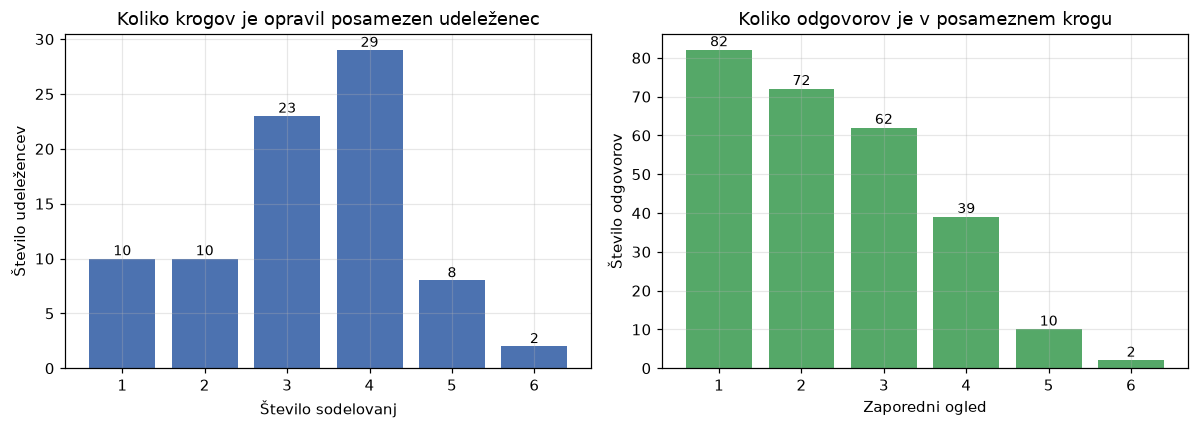

Povprecno sodelovanj na udelezenca: 3.26
Krogi 5 in 6 skupaj: 12 odgovorov


In [4]:
sodelovanja = df.groupby("analiza_resolved_code").size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

porazdelitev = sodelovanja.value_counts().sort_index()
ax1.bar(porazdelitev.index, porazdelitev.values, color="#4C72B0")
ax1.set_xlabel("Število sodelovanj")
ax1.set_ylabel("Število udeležencev")
ax1.set_title("Koliko krogov je opravil posamezen udeleženec")
for x, y in zip(porazdelitev.index, porazdelitev.values):
    ax1.text(x, y + 0.3, str(y), ha="center", fontsize=9)

po_ogledih = df.groupby("analiza_view_number").size()
ax2.bar(po_ogledih.index, po_ogledih.values, color="#55A868")
ax2.set_xlabel("Zaporedni ogled")
ax2.set_ylabel("Število odgovorov")
ax2.set_title("Koliko odgovorov je v posameznem krogu")
for x, y in zip(po_ogledih.index, po_ogledih.values):
    ax2.text(x, y + 1, str(y), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(GRAFI / "01_sodelovanja.png", bbox_inches="tight")
plt.show()

print(f"Povprecno sodelovanj na udelezenca: {sodelovanja.mean():.2f}")
print(f"Krogi 5 in 6 skupaj: {int(po_ogledih.get(5, 0) + po_ogledih.get(6, 0))} odgovorov")

Kroga 5 in 6 sta skoraj prazna. Zato čas v modelu obravnavamo kot **zvezno** spremenljivko
(linearni trend) in ne kot faktor — za faktor bi bili ti dve oceni nezanesljivi.

### 2.2 Povprečni odgovori po postavkah

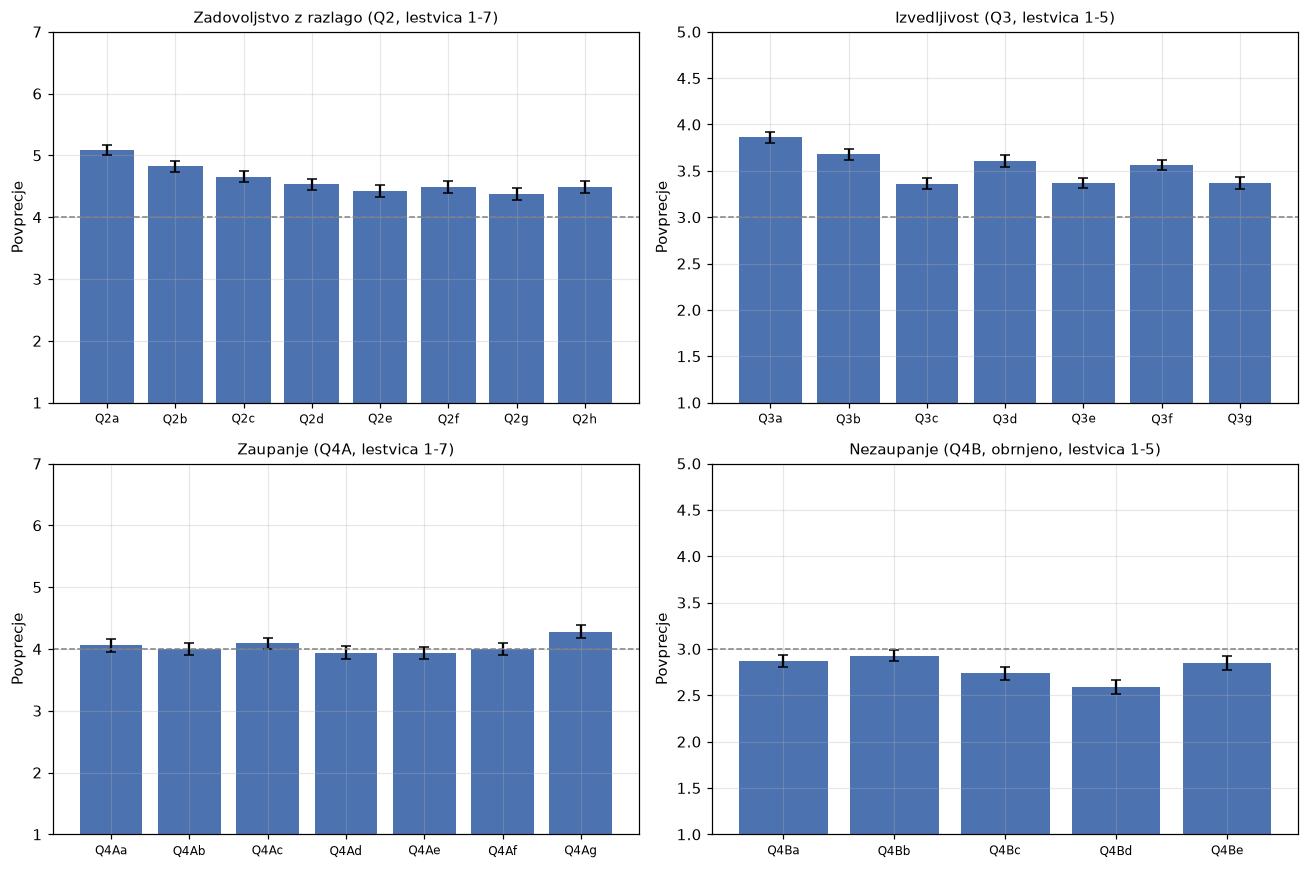

In [5]:
SKLOPI = {
    "Zadovoljstvo z razlago (Q2, lestvica 1-7)": (
        [f"analiza_zadovoljstvo_q2{c}_clean_1_7" for c in "abcdefgh"],
        [f"Q2{c}" for c in "abcdefgh"],
        7,
    ),
    "Izvedljivost (Q3, lestvica 1-5)": (
        [f"analiza_izvedljivost_q3{c}_clean_1_5" for c in "abcdefg"],
        [f"Q3{c}" for c in "abcdefg"],
        5,
    ),
    "Zaupanje (Q4A, lestvica 1-7)": (
        [f"analiza_trust_new_q4a{c}" for c in "abcdefg"],
        [f"Q4A{c}" for c in "abcdefg"],
        7,
    ),
    "Nezaupanje (Q4B, obrnjeno, lestvica 1-5)": (
        [f"analiza_nezaupanje_t{i}_recoded_1_5" for i in range(1, 6)],
        [f"Q4B{c}" for c in "abcde"],
        5,
    ),
}

fig, osi = plt.subplots(2, 2, figsize=(12, 8))
for ax, (naslov, (stolpci, oznake, vrh)) in zip(osi.flat, SKLOPI.items()):
    povprecja = [pd.to_numeric(df[s], errors="coerce").mean() for s in stolpci]
    napake = [
        pd.to_numeric(df[s], errors="coerce").sem() for s in stolpci
    ]
    ax.bar(oznake, povprecja, yerr=napake, capsize=3, color="#4C72B0")
    ax.set_ylim(1, vrh)
    ax.axhline((1 + vrh) / 2, color="grey", linestyle="--", linewidth=1)
    ax.set_title(naslov, fontsize=10)
    ax.set_ylabel("Povprecje")
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig(GRAFI / "02_povprecja_postavk.png", bbox_inches="tight")
plt.show()

Črtkana črta je sredina lestvice. Pri nezaupanju je smer obrnjena: **višja vrednost pomeni
večje nezaupanje**.

### 2.3 Pravilnost mentalnega modela

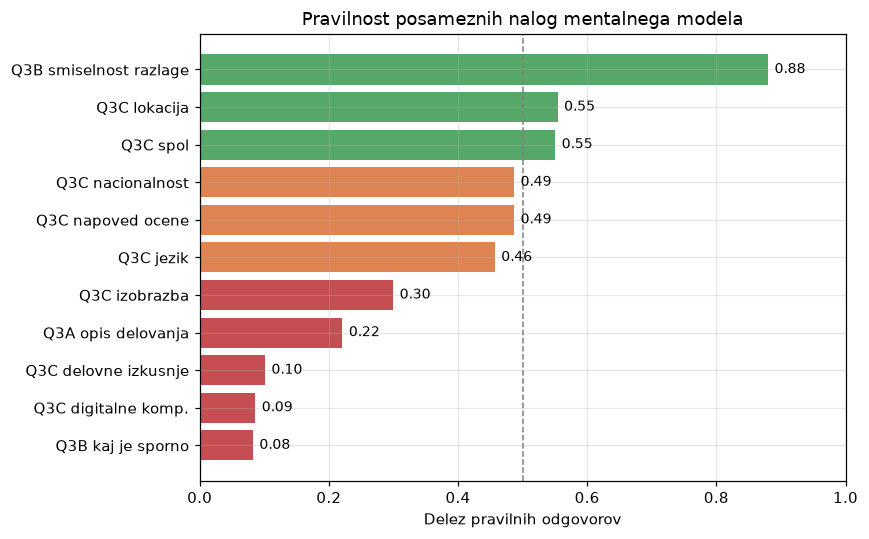

Skupni delez pravilnih: 0.382


In [6]:
MM_STOLPCI = {
    "analiza_mm_q3a_correct": "Q3A opis delovanja",
    "analiza_mm_q3b2_correct": "Q3B smiselnost razlage",
    "analiza_mm_q3b3_correct": "Q3B kaj je sporno",
    "analiza_mm_q3c2_correct": "Q3C napoved ocene",
    "analiza_mm_q3c_3a_correct": "Q3C izobrazba",
    "analiza_mm_q3c_3b_correct": "Q3C delovne izkusnje",
    "analiza_mm_q3c_3c_correct": "Q3C jezik",
    "analiza_mm_q3c_3d_correct": "Q3C digitalne komp.",
    "analiza_mm_q3c_3e_correct": "Q3C spol",
    "analiza_mm_q3c_3f_correct": "Q3C lokacija",
    "analiza_mm_q3c_3g_correct": "Q3C nacionalnost",
}

delezi = pd.Series(
    {opis: pd.to_numeric(df[st], errors="coerce").mean() for st, opis in MM_STOLPCI.items()}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
barve = ["#C44E52" if v < 0.33 else "#DD8452" if v < 0.5 else "#55A868" for v in delezi.values]
ax.barh(delezi.index, delezi.values, color=barve)
ax.set_xlabel("Delez pravilnih odgovorov")
ax.set_xlim(0, 1)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title("Pravilnost posameznih nalog mentalnega modela")
for i, v in enumerate(delezi.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(GRAFI / "03_mentalni_model.png", bbox_inches="tight")
plt.show()

print(f"Skupni delez pravilnih: {df['analiza_mm_total_correct_share'].mean():.3f}")

### 2.4 Potek dimenzij skozi kroge

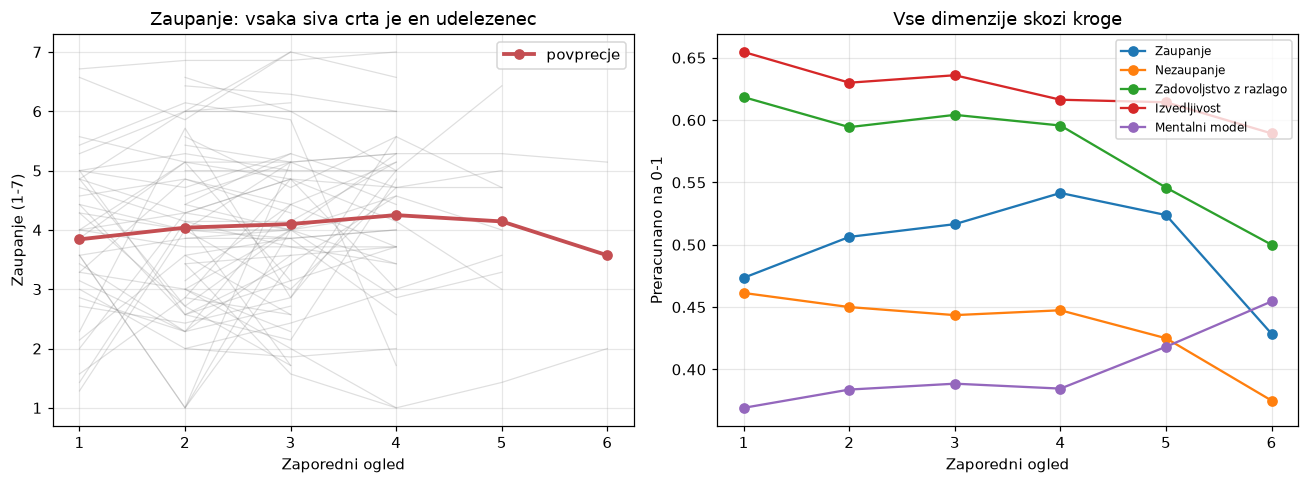

In [7]:
fig, osi = plt.subplots(1, 2, figsize=(12, 4.5))

# Levo: posamezne poti udelezencev z vsaj tremi meritvami zaupanja.
d_trust = df.dropna(subset=["analiza_faktor_zaupanje_mean"])
for _, skupina in d_trust.groupby("analiza_resolved_code"):
    if len(skupina) >= 3:
        skupina = skupina.sort_values("analiza_view_number")
        osi[0].plot(
            skupina["analiza_view_number"],
            skupina["analiza_faktor_zaupanje_mean"],
            color="grey", alpha=0.25, linewidth=0.8,
        )
povpr = d_trust.groupby("analiza_view_number")["analiza_faktor_zaupanje_mean"].mean()
osi[0].plot(povpr.index, povpr.values, color="#C44E52", linewidth=2.5, marker="o", label="povprecje")
osi[0].set_xlabel("Zaporedni ogled")
osi[0].set_ylabel("Zaupanje (1-7)")
osi[0].set_title("Zaupanje: vsaka siva crta je en udelezenec")
osi[0].legend()

# Desno: vse dimenzije, preracunane na 0-1 zaradi primerljivosti.
for ime, (stolpec, lestvica) in DIMENZIJE.items():
    serija = df.groupby("analiza_view_number")[stolpec].mean()
    if lestvica == "1-7":
        serija = (serija - 1) / 6
    elif lestvica == "1-5":
        serija = (serija - 1) / 4
    osi[1].plot(serija.index, serija.values, marker="o", label=ime)
osi[1].set_xlabel("Zaporedni ogled")
osi[1].set_ylabel("Preracunano na 0-1")
osi[1].set_title("Vse dimenzije skozi kroge")
osi[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(GRAFI / "04_potek_skozi_kroge.png", bbox_inches="tight")
plt.show()

Levi graf pokaže, zakaj navadni testi tu ne delujejo: udeleženci se med seboj razlikujejo
veliko bolj kot se posameznik spreminja skozi čas. Prav to razliko mešani model odstrani.

## 3. Linearni mešani modeli

**Zakaj mešani model.** Podatki niso neodvisni — 267 odgovorov prihaja od 82 udeležencev,
vsak je odgovarjal do šestkrat. Navadni test bi predpostavil 267 neodvisnih oseb in dal
prenizke *p*-vrednosti.

**Zgradba modela:**

```
dimenzija ~ zaporedni_ogled + tip_pristranskosti + (1 | udeleženec)
```

- **Fiksna učinka** — kar nas zanima: čas (H1) in pristranskost (H4)
- **Naključni učinek** — vsak udeleženec dobi svoje izhodišče, zato model meri spremembo
  *znotraj* osebe

V `statsmodels` je naključni presek privzet, ko podaš `groups=`.

### 3.1 Zaupanje

In [8]:
def mesani_model(podatki, odvisna, oznaka):
    """Prilagodi linearni mesani model in izpise pregledno tabelo."""
    d = podatki.dropna(subset=[odvisna, "analiza_view_number", "bias"]).copy()
    model = smf.mixedlm(
        f"{odvisna} ~ analiza_view_number + C(bias)",
        d,
        groups=d["analiza_resolved_code"],
    ).fit()

    var_med = float(model.cov_re.iloc[0, 0])
    icc = var_med / (var_med + model.scale)

    print(f"=== {oznaka} ===")
    print(f"N = {len(d)} odgovorov, {d['analiza_resolved_code'].nunique()} udelezencev")
    print(f"ICC = {icc:.3f}  (delez variance, ki gre na racun razlik med udelezenci)")
    print(model.summary().tables[1])
    print()
    return model


model_zaupanje = mesani_model(df, "analiza_faktor_zaupanje_mean", "ZAUPANJE (1-7)")

=== ZAUPANJE (1-7) ===
N = 238 odgovorov, 80 udelezencev
ICC = 0.571  (delez variance, ki gre na racun razlik med udelezenci)
                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                3.765    0.195  19.316  0.000   3.383  4.147
C(bias)[T.pozitivni_bias_nacionalnost]   0.337    0.181   1.860  0.063  -0.018  0.693
C(bias)[T.negativni_bias_nacionalnost]  -0.336    0.173  -1.942  0.052  -0.675  0.003
analiza_view_number                      0.111    0.057   1.957  0.050  -0.000  0.222
Group Var                                1.038    0.293                              



**Kako brati izpis:**

| Vrstica | Pomen |
|---|---|
| `Intercept` | Pričakovano zaupanje pri nepristranskem življenjepisu, izhodiščni ogled |
| `analiza_view_number` | Sprememba zaupanja **na vsak nadaljnji ogled** → odgovor na H1 |
| `C(bias)[T.pozitivni...]` | Razlika glede na nepristranski pogoj → odgovor na H4 |
| `C(bias)[T.negativni...]` | Razlika glede na nepristranski pogoj → odgovor na H4 |
| `Group Var` | Koliko se udeleženci med seboj razlikujejo |

`P>|z|` pod 0,05 pomeni statistično značilen učinek.

### 3.2 Zakaj pristranskost ni binarna spremenljivka

Pomembna metodološka odločitev. V podatkih obstajata **dve nasprotni vrsti** pristranskosti:

- Živa Kopitar — *pozitivni* bias (nacionalnost šteje v korist)
- Amira Bašić — *negativni* bias (nacionalnost šteje v škodo)

Če ju združiš v eno spremenljivko `Biased = 1`, se nasprotna učinka med seboj izničita.
Spodnja primerjava to pokaže na dejanskih podatkih.

In [9]:
d = df.dropna(subset=["analiza_faktor_zaupanje_mean"]).copy()

model_binarni = smf.mixedlm(
    "analiza_faktor_zaupanje_mean ~ analiza_view_number + Biased",
    d,
    groups=d["analiza_resolved_code"],
).fit()

print("BINARNA pristranskost (Biased 0/1):")
print(model_binarni.summary().tables[1])
print()
print("TRINIVOJSKA pristranskost (tip biasa):")
print(model_zaupanje.summary().tables[1])

BINARNA pristranskost (Biased 0/1):
                      Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept             3.774    0.197  19.172  0.000   3.388  4.160
analiza_view_number   0.111    0.058   1.903  0.057  -0.003  0.225
Biased               -0.018    0.138  -0.133  0.894  -0.290  0.253
Group Var             0.989    0.274                              

TRINIVOJSKA pristranskost (tip biasa):
                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                3.765    0.195  19.316  0.000   3.383  4.147
C(bias)[T.pozitivni_bias_nacionalnost]   0.337    0.181   1.860  0.063  -0.018  0.693
C(bias)[T.negativni_bias_nacionalnost]  -0.336    0.173  -1.942  0.052  -0.675  0.003
analiza_view_number                      0.111    0.057   1.957  0.050  -0.000  0.222
Group Var                                1.038    0.293                              


Binarna različica pokaže učinek blizu nič in visoko *p*-vrednost — videti je, kot da
pristranskost nima nobenega vpliva. Trinivojska različica razkrije dva nasprotna učinka
skoraj enake velikosti, ki sta se v binarni različici odštela.

**V magistrskem delu uporabi trinivojsko različico** in to odločitev utemelji.

### 3.3 Ostale dimenzije

In [10]:
modeli = {"Zaupanje": model_zaupanje}
for ime, (stolpec, _) in DIMENZIJE.items():
    if ime == "Zaupanje":
        continue
    modeli[ime] = mesani_model(df, stolpec, ime.upper())

=== NEZAUPANJE ===
N = 238 odgovorov, 80 udelezencev
ICC = 0.429  (delez variance, ki gre na racun razlik med udelezenci)
                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                2.860    0.125  22.962  0.000   2.616  3.104
C(bias)[T.pozitivni_bias_nacionalnost]   0.003    0.124   0.024  0.980  -0.240  0.246
C(bias)[T.negativni_bias_nacionalnost]   0.021    0.119   0.175  0.861  -0.213  0.255
analiza_view_number                     -0.022    0.039  -0.577  0.564  -0.099  0.054
Group Var                                0.286    0.135                              



=== ZADOVOLJSTVO Z RAZLAGO ===
N = 267 odgovorov, 82 udelezencev
ICC = 0.622  (delez variance, ki gre na racun razlik med udelezenci)
                                         Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                4.657    0.154  30.201  0.000   4.355   4.960
C(bias)[T.pozitivni_bias_nacionalnost]   0.361    0.143   2.516  0.012   0.080   0.642
C(bias)[T.negativni_bias_nacionalnost]  -0.295    0.138  -2.134  0.033  -0.565  -0.024
analiza_view_number                     -0.025    0.042  -0.597  0.550  -0.107   0.057
Group Var                                0.928    0.291                               



=== IZVEDLJIVOST ===
N = 267 odgovorov, 82 udelezencev
ICC = 0.586  (delez variance, ki gre na racun razlik med udelezenci)
                                         Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                3.625    0.094  38.499  0.000   3.440   3.809
C(bias)[T.pozitivni_bias_nacionalnost]   0.102    0.090   1.127  0.260  -0.075   0.279
C(bias)[T.negativni_bias_nacionalnost]  -0.274    0.087  -3.146  0.002  -0.444  -0.103
analiza_view_number                     -0.021    0.026  -0.798  0.425  -0.073   0.031
Group Var                                0.319    0.160                               



=== MENTALNI MODEL ===
N = 267 odgovorov, 82 udelezencev
ICC = 0.359  (delez variance, ki gre na racun razlik med udelezenci)
                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                0.358    0.022  15.963  0.000   0.314  0.402
C(bias)[T.pozitivni_bias_nacionalnost]   0.018    0.025   0.717  0.474  -0.031  0.066
C(bias)[T.negativni_bias_nacionalnost]  -0.005    0.024  -0.204  0.839  -0.051  0.042
analiza_view_number                      0.010    0.007   1.401  0.161  -0.004  0.024
Group Var                                0.010    0.022                              



### 3.4 Zbirna tabela vseh modelov

In [11]:
vrstice = []
for ime, model in modeli.items():
    for ucinek, oznaka in [
        ("analiza_view_number", "cas (na ogled)"),
        ("C(bias)[T.pozitivni_bias_nacionalnost]", "pozitivni bias"),
        ("C(bias)[T.negativni_bias_nacionalnost]", "negativni bias"),
    ]:
        if ucinek in model.params.index:
            p = model.pvalues[ucinek]
            vrstice.append(
                {
                    "dimenzija": ime,
                    "ucinek": oznaka,
                    "b": round(model.params[ucinek], 3),
                    "SE": round(model.bse[ucinek], 3),
                    "p": round(p, 3),
                    "znacilno": "da" if p < 0.05 else ("mejno" if p < 0.10 else "ne"),
                }
            )

zbirno = pd.DataFrame(vrstice)
zbirno.to_csv("rezultati_mesanih_modelov.csv", index=False, encoding="utf-8-sig")
zbirno

,dimenzija,ucinek,b,SE,p,znacilno
0,Zaupanje,cas (na ogled),0.111,0.057,0.050,mejno
1,Zaupanje,pozitivni bias,0.337,0.181,0.063,mejno
2,Zaupanje,negativni bias,-0.336,0.173,0.052,mejno
3,Nezaupanje,cas (na ogled),-0.022,0.039,0.564,ne
4,Nezaupanje,pozitivni bias,0.003,0.124,0.980,ne
5,Nezaupanje,negativni bias,0.021,0.119,0.861,ne
6,Zadovoljstvo z razlago,cas (na ogled),-0.025,0.042,0.550,ne
7,Zadovoljstvo z razlago,pozitivni bias,0.361,0.143,0.012,da
8,Zadovoljstvo z razlago,negativni bias,-0.295,0.138,0.033,da
9,Izvedljivost,cas (na ogled),-0.021,0.026,0.425,ne


## 4. Opombe za pisanje magistrskega dela

**Kaj je treba navesti med omejitvami:**

1. **Ni kontrolne skupine brez razlag.** Prvotni načrt je predvideval primerjavo skupine
   z razlagami in brez njih. Izveden eksperiment je imel razlage pri vseh šestih
   življenjepisih, zato H5 ni mogoče testirati kot primerjavo med pogojema.

2. **Pristranskost je vezana na dva konkretna življenjepisa.** Učinka pristranskosti ni
   mogoče ločiti od učinka teh dveh oseb (Živa Kopitar, Amira Bašić).

3. **Besedilo vprašanj Q4A in Q4B je napačno.** Navodilo se glasi »Razvrstite … od
   najpomembnejšega (1) do najmanj pomembnega (7)«, kar opisuje razvrščanje, postavke pa
   so trditve o zaupanju. Preverjeno: 97,5 % udeležencev je odgovarjalo kot na lestvici
   strinjanja (ponovljene vrednosti v vrstici), zato so podatki uporabni — a napako je
   treba priznati.

4. **Dve različici lestvice zaupanja.** 29 enot je izpolnilo starejšo različico in so
   izločene, zato modela za zaupanje in nezaupanje tečeta na N = 238 namesto 267.

5. **Kroga 5 in 6 sta skoraj prazna** (12 odgovorov skupaj).

**Odprto vprašanje za mentorico:** v deljenem dokumentu so beležke o tem, katere
spremenljivke uporabiti kje v MEM. Lokalni izvod dokumenta je iz 12. 11. 2025 in teh
beležk ne vsebuje — potrebna je aktualna različica.